# 17_04 — Evaluación predictiva · **Escenario A (FAR(1) con tendencia)**

Paso **3b** del ciclo. Supone que `17_03_convergencia` dio veredicto ✓; si las
cadenas no convergieron, nada de lo que sigue significa algo.

## Qué se reporta

| Sección | Qué responde |
|---|---|
| 4 | métricas puntuales y distribucionales, **train vs test** |
| 5 | bandas de credibilidad sobre la serie de cada score |
| 6 | intervalos sobre la curva, en extractos cada 10 períodos |
| 7 | ventana móvil: cómo evoluciona el error al cruzar $T_0$ |
| 8 | calibración: PIT por bloque |
| **9** | **anatomía del fallo: ¿es de nivel o de forma?** ← la sección propia |
| 10 | comparación con las líneas base |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.

---

## Cómo se lee este escenario

Cada escenario del estudio invierte la lectura de alguna métrica, y aquí la
inversión es doble.

**RMSE, R² y MISE sí discriminan, pero no del modo habitual.** En la corrida 11
la degradación train→test era ≈1.03 y las curvas de la ventana móvil eran
planas a ambos lados. Aquí se espera un **crecimiento monótono** dentro del
test, no un escalón: la deriva se acumula, de modo que el error del origen 400
debe ser mayor que el del 300. Un escalón plano sería el síntoma de que la
tendencia no entró.

**La cobertura debe desplomarse, y eso no es un fallo de la banda.** La banda
está bien construida —cubre la incertidumbre de la predictiva del modelo—; lo
que ocurre es que su **centro** está anclado a un nivel que dejó de ser válido.
Un modelo más flexible produciría la misma banda desplazada. La distinción
entre "banda demasiado angosta" y "banda bien dimensionada pero mal centrada"
es lo que §8 (forma del PIT) y §9 (descomposición nivel/forma) existen para
separar.

**La comparación relevante es contra persistencia, no contra la media
incondicional.** Ver `17_01 §6.1`: bajo tendencia la media incondicional está
anclada al bloque de entrenamiento y es pésima por construcción; ganarle no
dice nada. La persistencia, en cambio, des-tendencia implícitamente y es el
piso real que hay que superar.

**La advertencia estructural** —repetida en `_01 §2.5` y en el propio
`eval_config.json`—: $b(t)$ es monótona, de modo que los estratos por nivel de
deriva de §9.3 son intervalos temporales contiguos y el estrato alto coincide
casi con el bloque de prueba. §9.3 y §4 miden **lo mismo**. Es la tesis del
escenario, no un defecto, pero sin declararlo el desplome de cobertura se
leería como pérdida de *generalización* cuando es pérdida de *vigencia del
centrado*.

## 1. Imports, rutas y artefactos

In [2]:
1

1

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor, PropagadorFuncional

from model_psbp_fd.fit import (
    # puntual
    rmse_por_coeficiente, r2_por_columna, razon_dispersion, mise, rmse_funcional,
    # distribucional muestral
    crps_muestral, energy_score, cobertura, intervalo_muestral,
    pit_muestral, diagnostico_pit,
    # calibración condicional
    estratos_por_cuantil, cobertura_condicional,
    # agrupación de cadenas y ventana móvil
    agrupar_momentos, ventana_movil_scores, ventana_movil_funcional,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_bandas_serie, plot_extractos_curvas,
    plot_calibracion_pit, plot_scatter_theta,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [4]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 17_01, 17_03 y psbp_fd_iteracion.m
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", "A", 1
EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for r in PATHS.values():
    r.mkdir(parents=True, exist_ok=True)
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")

EXPERIMENT_ID : escenario_A_r01


In [5]:
dfs_train, manifest = cargar_datasets_ar(PATHS, bloque="train")
dfs_test,  _        = cargar_datasets_ar(PATHS, bloque="test")
hp_json     = cargar_hiperparametros(PATHS)
eval_config = cargar_config_evaluacion(PATHS)

COMPONENT_IDX = manifest["component_idx"]
n_components  = len(COMPONENT_IDX)
cov_names     = manifest["cov_names"]
N_LAGS        = int(manifest["n_lags"])
T, T0         = int(manifest["T"]), int(manifest["T0"])
N_ITER        = int(hp_json["n_iter"])
MCMC_CFG      = hp_json["mcmc_config"]
BURN          = int(MCMC_CFG["burn"])

assert manifest["scores_scale"] == "standardized_zscore_ddof0"

# Parámetros de evaluación: se LEEN del artefacto, no se redeclaran aquí.
NIVEL        = float(eval_config.get("nivel_credibilidad", 0.95))
MODO_RESIDUO = eval_config.get("modo_residuo", "ninguno")
OBJETIVO     = eval_config.get("objetivo_evaluacion", "curva_verdadera")
VENTANAS_W   = list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40]))

# ── Bloques propios del Escenario A ──────────────────────────────────────────
TEND = eval_config.get("tendencia")
EST  = eval_config.get("estratificacion")
assert TEND is not None, (
    "eval_config.json no declara 'tendencia'. Este notebook es del Escenario A; "
    "¿se apuntó al EXPERIMENT_ID equivocado?")
assert EST is not None and EST.get("variable") == "b_t", (
    "eval_config.json no declara la estratificación por b_t. Regenerar con 17_01.")
FPC_DERIVA = int(TEND["componente_deriva_fpc"])

print(f"T={T}  T0={T0}  n_lags={N_LAGS}  componentes={n_components}")
print(f"nivel={NIVEL}  ·  modo_residuo={MODO_RESIDUO!r}  ·  objetivo={OBJETIVO!r}")
print(f"ventanas w = {VENTANAS_W}")
print(f"\ntendencia: deriva={TEND['deriva_total']} forma={TEND['forma']!r} "
      f"inclinación={TEND['inclinacion']}  ·  FPC de la deriva = {FPC_DERIVA}")
print("\n" + "⚠ " + EST["advertencia"])

T=400  T0=280  n_lags=1  componentes=4
nivel=0.95  ·  modo_residuo='ninguno'  ·  objetivo='curva_verdadera'
ventanas w = [10, 20, 40]

tendencia: deriva=3.0 forma='lineal' inclinación=0.0  ·  FPC de la deriva = 1

⚠ b(t) es MONOTONA en t, de modo que los estratos por nivel de deriva son intervalos temporales contiguos y el estrato mas alto coincide casi exactamente con el bloque de prueba. La cobertura condicional de 17_04 §9 y la comparacion train/test de 17_04 §4 miden por tanto LO MISMO. Es la tesis del escenario, no un defecto, pero sin declararlo el desplome de cobertura se leeria como perdida de GENERALIZACION cuando es perdida de VIGENCIA DEL CENTRADO. Para separar ambos efectos habria que usar TEND_FORMA='cuadratica', que concentra la deriva dentro del test.


In [6]:
fpca = cargar_fpca(PATHS)
_ver = fpca.verificar()
assert _ver["todo_ok"], f"Las identidades FPCA no se cumplen: {_ver}"

scores_standardizer = cargar_estandarizador(PATHS, DataStandardizer)
X_obs, grilla = cargar_curvas(PATHS)                 # (T, G) con ruido
X_true        = cargar_curvas_true(PATHS)            # (T, G) verdadera — el objetivo

M_fpca   = fpca.M
Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES     = fpca.SCORES                              # (T, M) escala original
SCORES_STD = scores_standardizer.transform(SCORES)

print(f"FPCA M={M_fpca} K={fpca.K}   ·   curvas {X_true.shape}  grilla {grilla.shape}")
print(f"sd(observada − verdadera) = {(X_obs - X_true).std():.4f}   "
      "← el ruido que el modelo NO debe predecir")
assert COMPONENT_IDX == list(range(M_fpca)), (
    "La propagación funcional necesita el vector completo de scores en orden; "
    f"COMPONENT_IDX={COMPONENT_IDX} y M={M_fpca}.")

FPCA M=4 K=8   ·   curvas (400, 75)  grilla (75,)
sd(observada − verdadera) = 0.2503   ← el ruido que el modelo NO debe predecir


In [7]:
# Estado verdadero b(t), escrito por 17_01 §2.5. Es el insumo de §9.
estado_tend = pd.read_csv(PATHS["out_report"] / "10_estado_tendencia.csv")
assert len(estado_tend) == T, f"10_estado_tendencia.csv tiene {len(estado_tend)} filas ≠ T={T}."
b_t_full = estado_tend["b_t"].to_numpy()

# Forma de la deriva, reconstruida de los parámetros declarados (no se re-elige).
g_tau = 1.0 + float(TEND["inclinacion"]) * (grilla - 0.5)
assert abs(float(g_tau.mean()) - float(TEND["g_medio"])) < 1e-10, \
    "g(tau) reconstruida no coincide con la declarada en eval_config."

print(f"b(t): b(1)={b_t_full[0]:.3f}  b(T0)={b_t_full[T0-1]:.3f}  b(T)={b_t_full[-1]:.3f}")
print(f"desfase train↔test = {b_t_full[T0:].mean() - b_t_full[:T0].mean():+.3f}")

b(t): b(1)=0.000  b(T0)=2.098  b(T)=3.000
desfase train↔test = +1.504


## 2. Trazas MCMC

In [8]:
def ruta_traza(fpc_idx, chain):
    return PATHS["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path):
    m = loadmat(str(path))
    claves = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
              "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in claves}
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    def __init__(self, traces, burn, feature_names):
        self.traces = traces
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def momentos(self, df):
        return self.predictor_.momentos_predictivos(self._diseno(df))

    def muestrear(self, df, d=1, seed=None):
        return self.predictor_.muestrear(self._diseno(df), d, seed=seed)


faltan = [ruta_traza(COMPONENT_IDX[k] + 1, c + 1).name
          for k in range(n_components) for c in range(N_ITER)
          if not ruta_traza(COMPONENT_IDX[k] + 1, c + 1).exists()]
assert not faltan, f"Faltan trazas: {faltan}. Ejecuta psbp_fd_iteracion.m."

models_chains = {k: {} for k in range(n_components)}
for k in range(n_components):
    esperado = list(dfs_train[k].columns[1:])
    for c in range(N_ITER):
        traces, burn, feat = leer_traza(ruta_traza(COMPONENT_IDX[k] + 1, c + 1))
        assert feat == esperado, f"[k={k} c={c+1}] feature_names ≠ columnas del dataset."
        models_chains[k][c] = ModeloTraza(traces, burn, feat)

n_post = MCMC_CFG["nsim"] - BURN
print(f"✓ {n_components} × {N_ITER} cadenas · {n_post} draws posteriores c/u")

✓ 4 × 3 cadenas · 1500 draws posteriores c/u


## 3. Predicción a $h=1$ sobre la serie completa

Los dos bloques se concatenan en **una sola serie de orígenes**
$t=N_{lags}+1,\dots,T$. Sin el tramo de entrenamiento no hay con qué comparar la
evolución al cruzar $T_0$, que es la lectura principal de la ventana móvil.

En todos los orígenes la predicción usa los **rezagos reales** —nunca
predicciones encadenadas—, de modo que el horizonte es 1 en todo el recorrido y
el modelo no se reentrena en ningún punto. Bajo tendencia esto importa
especialmente: con predicciones encadenadas el error se acumularía por
composición y no se podría distinguir del efecto de la deriva.

In [9]:
S_POR_ITER = 100
SEED_PRED  = 20260823

dfs_full = {k: pd.concat([dfs_train[k], dfs_test[k]], ignore_index=True)
            for k in range(n_components)}
n_orig   = len(dfs_full[0])
t_orig   = np.arange(N_LAGS + 1, T + 1)          # tiempo del experimento, base-1
assert len(t_orig) == n_orig, f"{len(t_orig)} ≠ {n_orig}"

T0_orig  = T0 - N_LAGS
es_train = t_orig <= T0
b_t_ev   = b_t_full[N_LAGS:]                     # (n_orig,) estado alineado a los orígenes
assert len(b_t_ev) == n_orig

print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

orígenes evaluados: 399  (train 279 · test 120)


In [10]:
Y_obs  = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy() for k in range(n_components)])
Y_hat  = np.empty_like(Y_obs)
Y_sd   = np.empty_like(Y_obs)
draws  = []          # por componente: (S, n_orig)

for k in range(n_components):
    medias, sds, muestras_k = [], [], []
    for c in sorted(models_chains[k]):
        mom = models_chains[k][c].momentos(dfs_full[k])
        medias.append(mom["media"])
        sds.append(mom["sd"])            # PREDICTIVA (v3), no la del centro
        muestras_k.append(models_chains[k][c].muestrear(
            dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c))
    Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                               np.column_stack(sds))
    draws.append(np.concatenate(muestras_k, axis=0))

SC_draws = np.stack(draws, axis=2)                  # (S, n_orig, M)
S_total  = SC_draws.shape[0]
li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)   # (n_orig, M)

print(f"extracciones por score: S = {S_total} "
      f"= {n_post} draws × {S_POR_ITER} × {N_ITER} cadenas")
print(f"SC_draws {SC_draws.shape}  ·  bandas {li_s.shape}")

extracciones por score: S = 450000 = 1500 draws × 100 × 3 cadenas
SC_draws (450000, 399, 4)  ·  bandas (399, 4)


### 3.1 Propagación a la curva

$\hat X^{(s)}_t(\tau)=\mu(\tau)+\sum_m (d_m\tilde\xi^{(s)}_{tm}+c_m)\psi_m(\tau)$.
Con `modo_residuo="ninguno"` el mapa es determinista y las curvas son
extracciones exactas de la predictiva de la curva **proyectada**.

Nótese que $\mu(\tau)$ aquí es la **media funcional empírica del bloque de
entrenamiento**, no la $\mu$ del generador. Ésa es la vía por la que el sesgo de
nivel entra en la reconstrucción, y por eso §9 puede aislarlo.

In [11]:
S_FUNC = 500
paso_thin = max(1, S_total // S_FUNC)
SC_thin = SC_draws[::paso_thin]

propagador = PropagadorFuncional(Psi_grid, mu_grid,
                                 estandarizador=scores_standardizer,
                                 modo_residuo=MODO_RESIDUO)
X_draws = propagador.curvas_desde_scores(SC_thin, seed=SEED_PRED)   # (S', n, G)
X_pred  = X_draws.mean(axis=0)                                       # (n, G)
li_f, ls_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0), \
             np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

X_true_ev = X_true[N_LAGS:]     # (n_orig, G) VERDADERA — contra esto se evalúa
X_obs_ev  = X_obs[N_LAGS:]      # (n_orig, G) observada, sólo para las figuras

print(f"muestras funcionales {X_draws.shape}  (adelgazado 1 de cada {paso_thin})")
print(f"memoria ≈ {X_draws.nbytes / 1e6:.0f} MB")

# Piso de error: la mejor curva alcanzable con M componentes, sin modelo alguno.
X_proj = fpca.reconstruct(SCORES)[N_LAGS:]
print(f"\nMISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): "
      f"{mise(X_true_ev, X_proj, grilla):.6f}")
print("   ← ningún modelo sobre esta representación puede bajar de ahí")
print(f"  train: {mise(X_true_ev[es_train], X_proj[es_train], grilla):.6f}   "
      f"test: {mise(X_true_ev[~es_train], X_proj[~es_train], grilla):.6f}")
print("  Si el piso de test es MUCHO mayor que el de train, la propia base "
      "perdió vigencia\n  (efecto (2) de 17_01) y no sólo el centrado.")

muestras funcionales (500, 399, 75)  (adelgazado 1 de cada 900)
memoria ≈ 120 MB

MISE del TRUNCAMIENTO (proyección FPCA de la curva verdadera): 0.039375
   ← ningún modelo sobre esta representación puede bajar de ahí
  train: 0.038657   test: 0.041043
  Si el piso de test es MUCHO mayor que el de train, la propia base perdió vigencia
  (efecto (2) de 17_01) y no sólo el centrado.


## 4. Métricas, entrenamiento contra prueba

En la corrida 11 —FAR(1) estacionario— las dos columnas se parecían
(`RMSE test / train = 1.027`). Aquí la degradación debe ser **grande**, y esa
razón es la primera cifra reportable del escenario.

In [12]:
def _metricas_bloque(mask, etiqueta):
    """Métricas puntuales y distribucionales sobre un subconjunto de orígenes."""
    filas = []
    for k in range(n_components):
        y, p = Y_obs[mask, k], Y_hat[mask, k]
        z    = SC_draws[:, mask, k]
        cob  = cobertura(y, li_s[mask, k], ls_s[mask, k])
        pit  = pit_muestral(y, z)
        filas.append({
            "bloque":  etiqueta,
            "FPC":     f"FPC {COMPONENT_IDX[k] + 1}"
                       + (" [deriva]" if COMPONENT_IDX[k] + 1 == FPC_DERIVA else ""),
            "RMSE":    float(rmse_por_coeficiente(y[:, None], p[:, None])[0]),
            "R2":      float(r2_por_columna(y[:, None], p[:, None], centrar=True)[0]),
            "sd_ratio": float(razon_dispersion(y[:, None], p[:, None])[0]),
            "CRPS":    float(crps_muestral(y, z).mean()),
            f"Cob{int(NIVEL*100)}": cob["cobertura"],
            "Ancho":   cob["ancho_medio"],
            "PIT_ks":  float(diagnostico_pit(pit)["ks"]),
            "PIT_forma": diagnostico_pit(pit)["forma"],
            "n":       int(mask.sum()),
        })
    return filas

met_df = pd.DataFrame(_metricas_bloque(es_train, "train")
                      + _metricas_bloque(~es_train, "test"))
met_df = met_df.set_index(["bloque", "FPC"])
met_df.to_csv(PATHS["out_report"] / "50_metricas_scores.csv")

_num = [c for c in met_df.columns if met_df[c].dtype.kind == "f"]
display(met_df.style
    .format({c: "{:.4f}" for c in _num})
    .background_gradient(subset=["RMSE", "CRPS"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=[f"Cob{int(NIVEL*100)}"], cmap="RdYlGn",
                         vmin=0.80, vmax=1.0)
    .set_caption("Métricas por score y bloque · CRPS y cobertura desde la "
                 "predictiva MUESTRAL"))

RMSE_RATIO_C11 = 1.027   # referencia de la corrida 11 (estacionaria)
_deg = (met_df.loc["test", "RMSE"].mean() / met_df.loc["train", "RMSE"].mean())
print(f"\nRMSE test / RMSE train = {_deg:.3f}   "
      f"(corrida 11, estacionaria: {RMSE_RATIO_C11})")
if _deg < 1.15:
    print("  ⚠ Sin degradación apreciable: la tendencia NO está produciendo efecto.\n"
          "    Revisar TEND_DERIVA en 17_01 §2.2.")
else:
    print(f"  ✓ El modelo se degrada {_deg / RMSE_RATIO_C11:.1f}× más que en el caso "
          f"estacionario.")


RMSE test / RMSE train = 1.127   (corrida 11, estacionaria: 1.027)
  ⚠ Sin degradación apreciable: la tendencia NO está produciendo efecto.
    Revisar TEND_DERIVA en 17_01 §2.2.


In [13]:
# Métricas funcionales, contra la curva VERDADERA
filas_f = []
for mask, etq in ((es_train, "train"), (~es_train, "test")):
    dentro = (X_true_ev[mask] >= li_f[mask]) & (X_true_ev[mask] <= ls_f[mask])
    filas_f.append({
        "bloque": etq,
        "MISE":   mise(X_true_ev[mask], X_pred[mask], grilla),
        "RMSE_f": rmse_funcional(X_true_ev[mask], X_pred[mask], grilla),
        "MISE_truncamiento": mise(X_true_ev[mask], X_proj[mask], grilla),
        "energy": energy_score(X_true_ev[mask], X_draws[:, mask, :],
                               max_pares=2000, seed=0),
        f"Cob{int(NIVEL*100)}_puntual": float(dentro.mean()),
        "ancho_medio": float((ls_f[mask] - li_f[mask]).mean()),
        "n": int(mask.sum()),
    })
fun_df = pd.DataFrame(filas_f).set_index("bloque")
fun_df.to_csv(PATHS["out_report"] / "51_metricas_funcionales.csv")

display(fun_df.style.format("{:.6f}", subset=["MISE", "RMSE_f", "MISE_truncamiento"])
        .format("{:.4f}", subset=["energy", f"Cob{int(NIVEL*100)}_puntual", "ancho_medio"])
        .set_caption("Métricas funcionales contra la curva VERDADERA · "
                     "banda sin residuo de representación"))

_frac = fun_df["MISE_truncamiento"] / fun_df["MISE"]
print("\nfracción del MISE atribuible al truncamiento FPCA:")
for b in fun_df.index:
    print(f"  {b:5s}: {_frac[b]:.1%}")
print(f"\nMISE test / MISE train = {fun_df.loc['test','MISE'] / fun_df.loc['train','MISE']:.2f}×")
print(f"Cobertura: train {fun_df.loc['train', f'Cob{int(NIVEL*100)}_puntual']:.3f}  →  "
      f"test {fun_df.loc['test', f'Cob{int(NIVEL*100)}_puntual']:.3f}   "
      f"(nominal {NIVEL})")
print("\nEl ancho medio de la banda es casi el mismo en ambos bloques: la banda no\n"
      "se estrechó, se descentró. §9 lo separa numéricamente.")

,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,1.039711,1.019662,0.038657,5.8309,0.9466,3.9618,279
test,1.282739,1.132581,0.041043,6.4406,0.9140,4.1626,120



fracción del MISE atribuible al truncamiento FPCA:
  train: 3.7%
  test : 3.2%

MISE test / MISE train = 1.23×
Cobertura: train 0.947  →  test 0.914   (nominal 0.95)

El ancho medio de la banda es casi el mismo en ambos bloques: la banda no
se estrechó, se descentró. §9 lo separa numéricamente.


## 5. Bandas de credibilidad sobre la serie de scores

[plot_bandas_serie] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.1s  FPC 1: cob train=0.961 (+0.011) test=0.892 (-0.058) | ancho train=2.716 test=3 | 24/399 fuera
  2/4 (50.0%) t=0.1s eta=0.1s  FPC 2: cob train=0.957 (+0.007) test=0.967 (+0.017) | ancho train=3.765 test=3.758 | 16/399 fuera
  3/4 (75.0%) t=0.1s eta=0.0s  FPC 3: cob train=0.957 (+0.007) test=0.858 (-0.092) | ancho train=3.949 test=3.961 | 29/399 fuera
  4/4 (100.0%) t=0.1s eta=0.0s  FPC 4: cob train=0.950 (-0.000) test=0.917 (-0.033) | ancho train=3.896 test=3.897 | 24/399 fuera
[plot_bandas_serie] listo: 4 pasos en 1.3s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_A_r01\52_bandas_scores.png


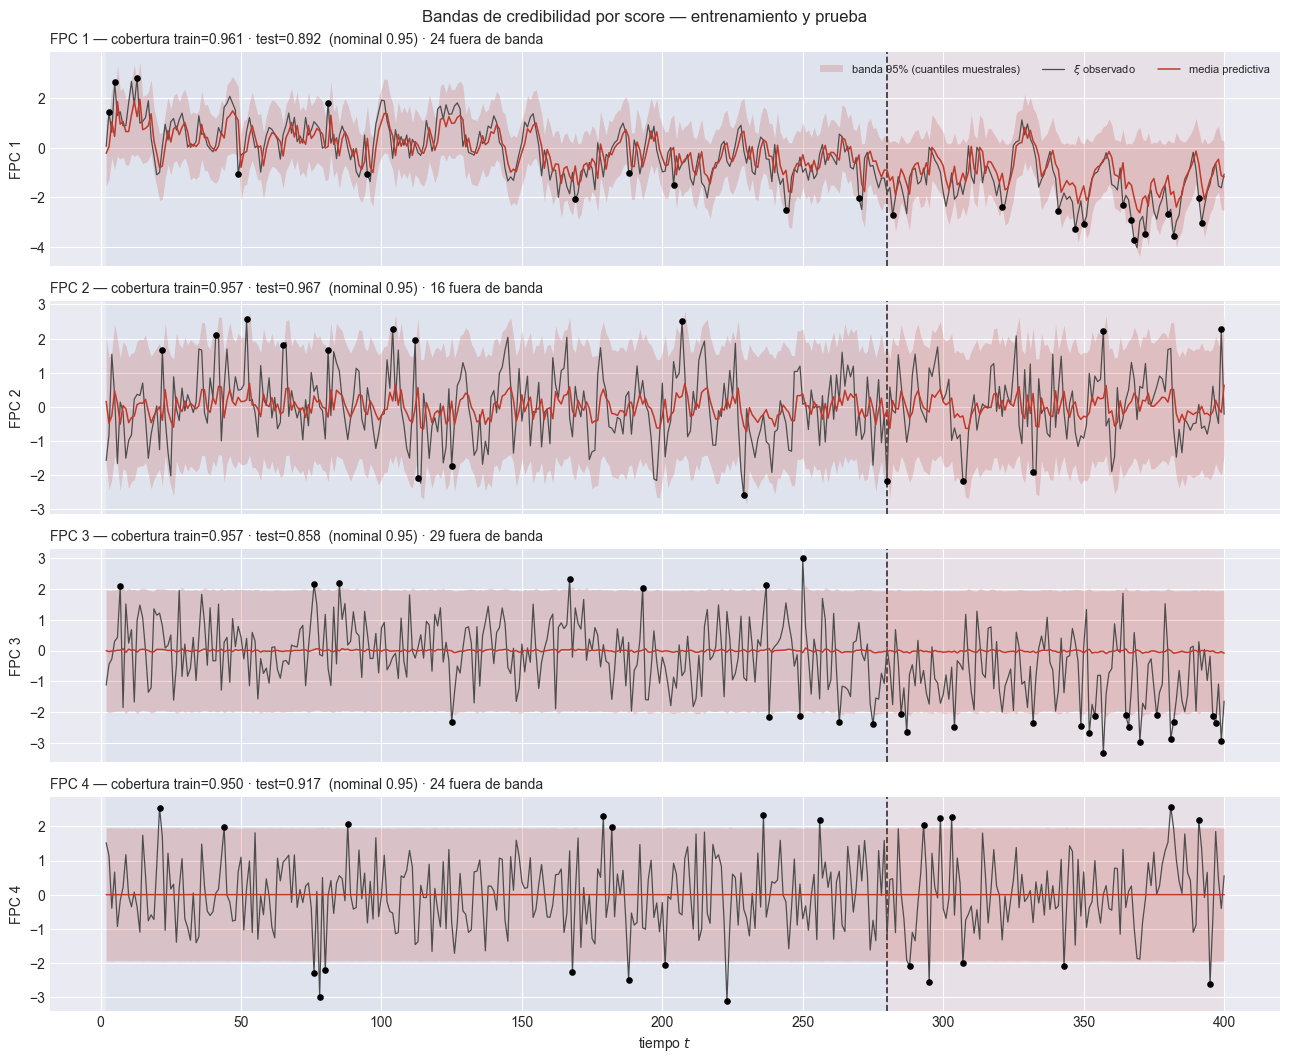

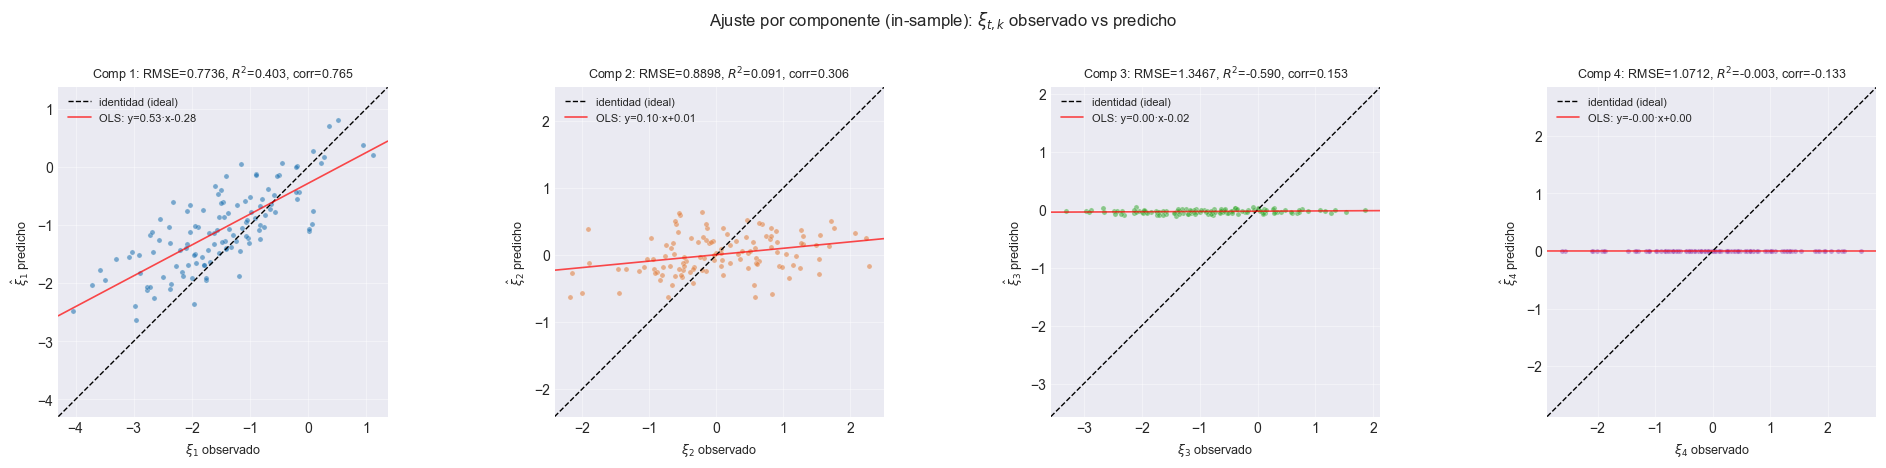

In [14]:
plot_bandas_serie(
    Y_obs, Y_hat, li_s, ls_s, T0, t=t_orig,
    etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX], nivel=NIVEL,
    title="Bandas de credibilidad por score — entrenamiento y prueba",
    save_path=str(PATHS["out_report"] / "52_bandas_scores.png"),
    verbose=True)
plt.show()

eval_scatter = {k: {"y_obs": Y_obs[~es_train, k], "y_hat": Y_hat[~es_train, k]}
                for k in range(n_components)}
plot_scatter_theta(eval_scatter, n_components=n_components,
                   save_path=str(PATHS["out_report"] / "53_scatter_scores_test.png"))
plt.show()

## 6. Intervalos de credibilidad sobre la curva

Extractos de la serie funcional cada `CADA` períodos, cada uno con su banda
puntual, la curva verdadera y —en gris— los datos observados.

En este escenario la lectura visual es directa: en el bloque de prueba la banda
debería quedar **sistemáticamente por debajo** de la curva verdadera, y el
desfase creciendo con $t$.

[plot_extractos_curvas] inicio (40 pasos)
  1/40 ( 2.5%) t=0.0s eta=0.3s  t=2 [train] cob=1.000 rmse=1.249
  2/40 ( 5.0%) t=0.0s eta=0.6s  t=12 [train] cob=1.000 rmse=0.7332
  4/40 (10.0%) t=0.1s eta=0.7s  t=32 [train] cob=1.000 rmse=0.5778
  6/40 (15.0%) t=0.1s eta=0.7s  t=52 [train] cob=0.720 rmse=1.721
  8/40 (20.0%) t=0.2s eta=0.7s  t=72 [train] cob=1.000 rmse=0.743
  10/40 (25.0%) t=0.2s eta=0.7s  t=92 [train] cob=1.000 rmse=0.7522
  12/40 (30.0%) t=0.3s eta=0.6s  t=112 [train] cob=0.893 rmse=1.236
  14/40 (35.0%) t=0.3s eta=0.6s  t=132 [train] cob=1.000 rmse=0.3755
  16/40 (40.0%) t=0.4s eta=0.6s  t=152 [train] cob=1.000 rmse=0.4769
  18/40 (45.0%) t=0.5s eta=0.6s  t=172 [train] cob=1.000 rmse=0.7612
  20/40 (50.0%) t=0.5s eta=0.5s  t=192 [train] cob=1.000 rmse=0.949
  22/40 (55.0%) t=0.5s eta=0.4s  t=212 [train] cob=0.973 rmse=0.8508
  24/40 (60.0%) t=0.6s eta=0.4s  t=232 [train] cob=1.000 rmse=1.157
  26/40 (65.0%) t=0.6s eta=0.3s  t=252 [train] cob=1.000 rmse=0.8238
  28/40 (7

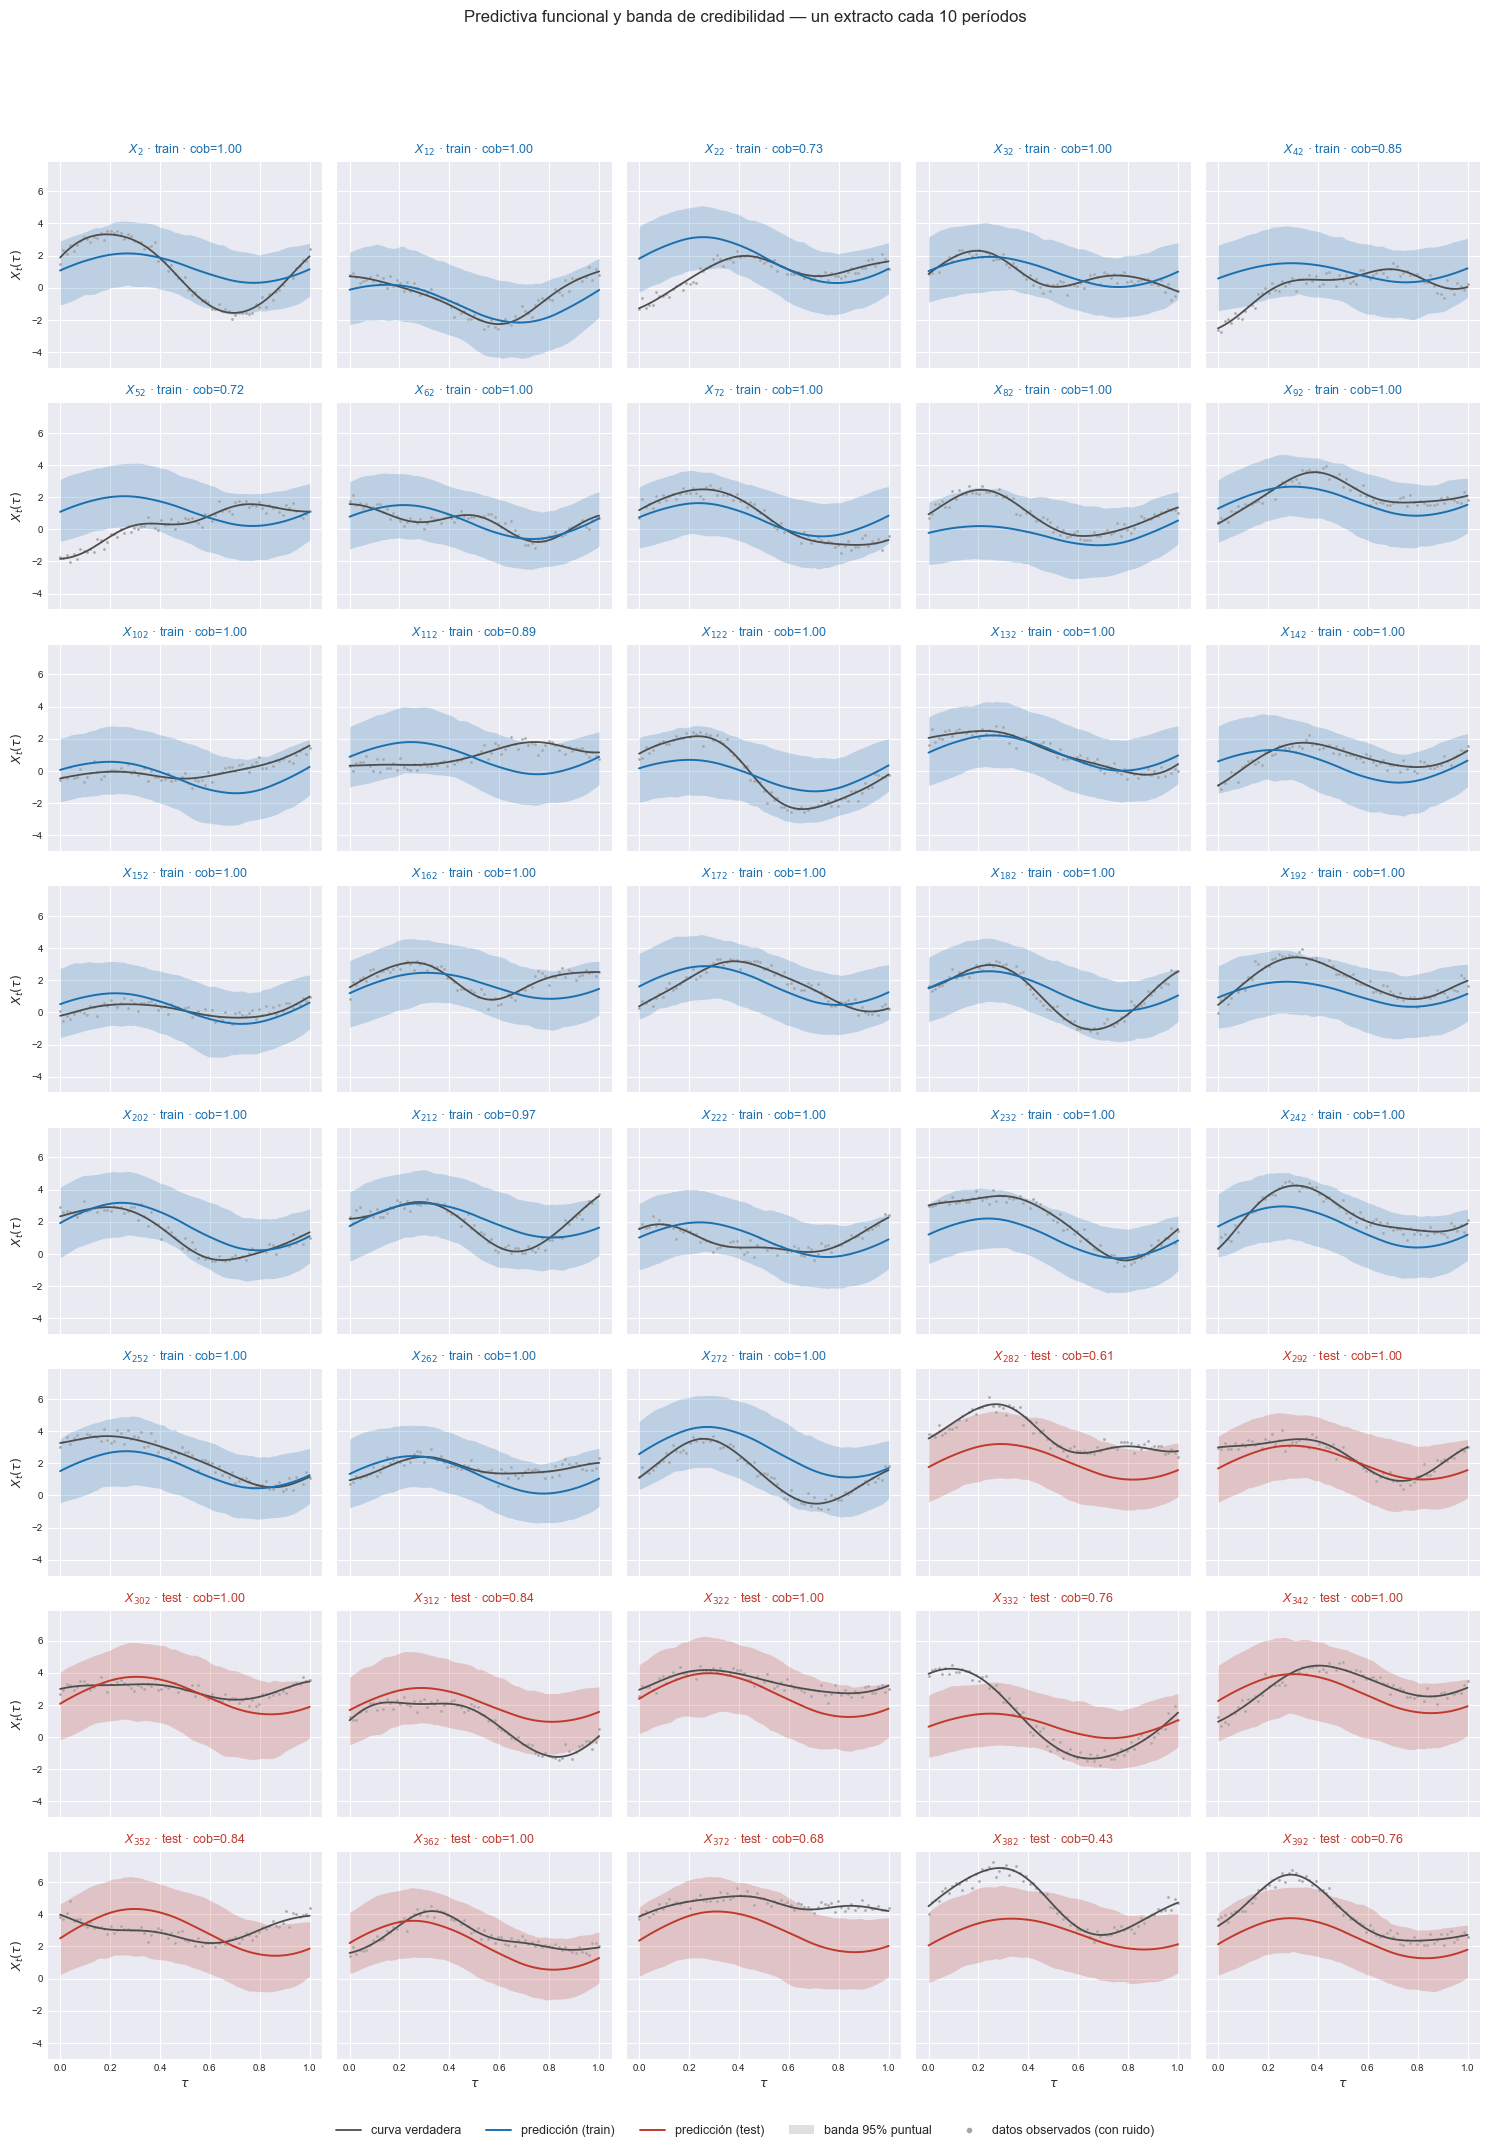

In [15]:
CADA = 10   # [CONFIG] un extracto cada CADA períodos

plot_extractos_curvas(
    X_true_ev, X_pred, li_f, ls_f, grilla, T0, t=t_orig,
    cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev,
    title="Predictiva funcional y banda de credibilidad",
    save_path=str(PATHS["out_report"] / "54_extractos_curvas.png"),
    verbose=True)
plt.show()

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=277 [train] cob=0.853 rmse=1.091
  2/7 (28.6%) t=0.0s eta=0.0s  t=278 [train] cob=1.000 rmse=0.8224
  3/7 (42.9%) t=0.0s eta=0.0s  t=279 [train] cob=1.000 rmse=0.6021
  4/7 (57.1%) t=0.0s eta=0.0s  t=280 [train] cob=0.760 rmse=1.556
  5/7 (71.4%) t=0.0s eta=0.0s  t=281 [test] cob=1.000 rmse=0.9402
  6/7 (85.7%) t=0.0s eta=0.0s  t=282 [test] cob=0.613 rmse=1.792
  7/7 (100.0%) t=0.0s eta=0.0s  t=283 [test] cob=1.000 rmse=0.4579
[plot_extractos_curvas] listo: 7 pasos en 1.2s  cob media train=0.903 test=0.871 (nominal 0.95)


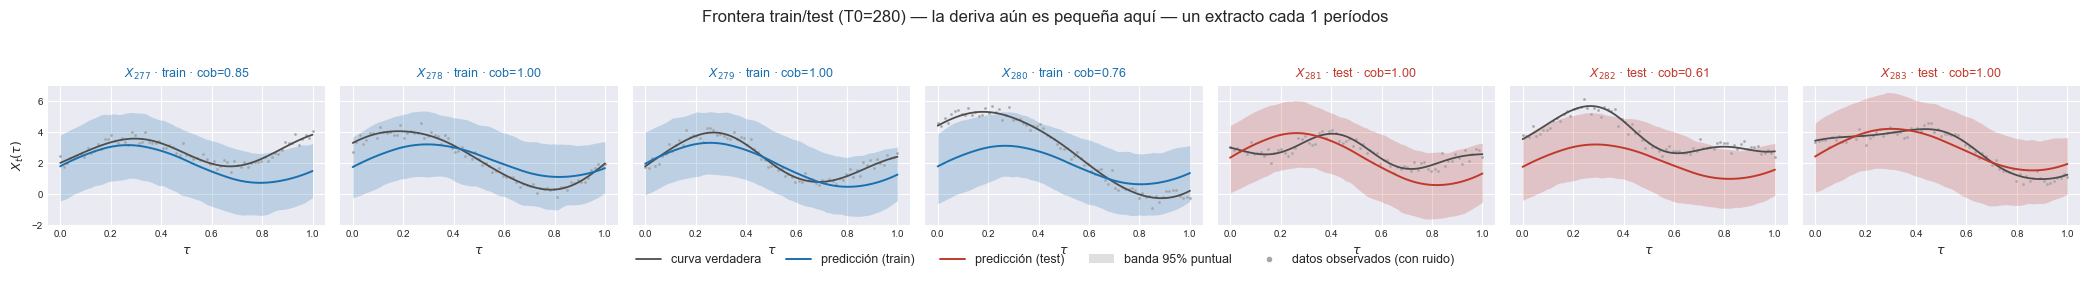

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=394 [test] cob=1.000 rmse=0.5594
  2/7 (28.6%) t=0.0s eta=0.0s  t=395 [test] cob=1.000 rmse=0.6911
  3/7 (42.9%) t=0.0s eta=0.0s  t=396 [test] cob=1.000 rmse=0.9625
  4/7 (57.1%) t=0.0s eta=0.0s  t=397 [test] cob=0.933 rmse=0.9716
  5/7 (71.4%) t=0.0s eta=0.0s  t=398 [test] cob=1.000 rmse=1.204
  6/7 (85.7%) t=0.0s eta=0.0s  t=399 [test] cob=0.693 rmse=1.838
  7/7 (100.0%) t=0.0s eta=0.0s  t=400 [test] cob=1.000 rmse=0.8081
[plot_extractos_curvas] listo: 7 pasos en 1.2s  cob media train=nan test=0.947 (nominal 0.95)


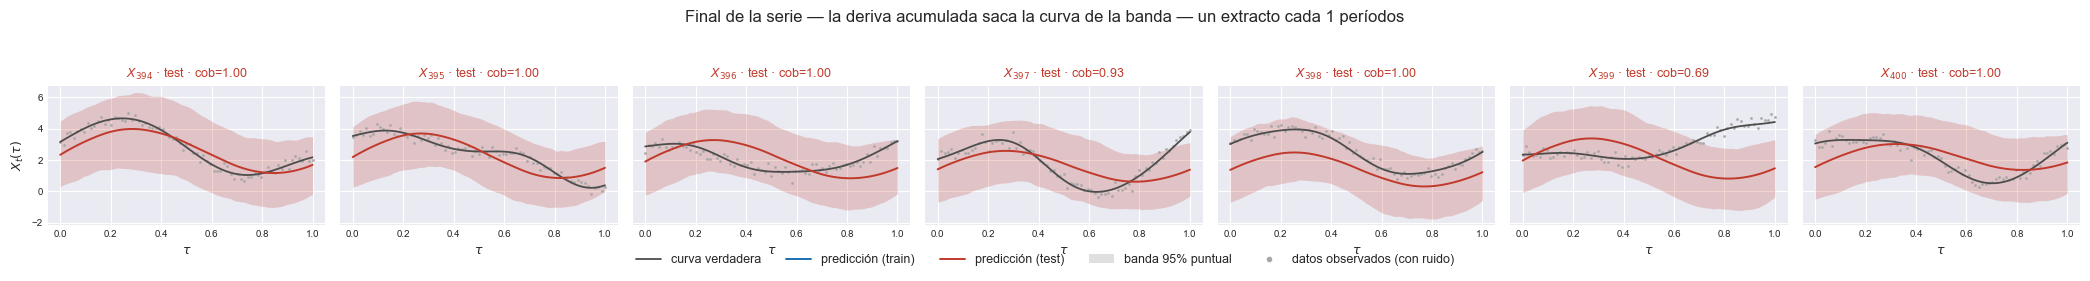

In [16]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

plot_extractos_curvas(
    X_true_ev[sel], X_pred[sel], li_f[sel], ls_f[sel], grilla, T0,
    t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL, X_obs=X_obs_ev[sel],
    title=f"Frontera train/test (T0={T0}) — la deriva aún es pequeña aquí",
    save_path=str(PATHS["out_report"] / "55_extractos_frontera.png"),
    verbose=True)
plt.show()

# Y el otro extremo, donde la deriva ya está acumulada: es la comparación que
# hace visible que el problema CRECE, no que salta.
sel2 = np.arange(n_orig - 7, n_orig)
plot_extractos_curvas(
    X_true_ev[sel2], X_pred[sel2], li_f[sel2], ls_f[sel2], grilla, T0,
    t=t_orig[sel2], cada=1, n_col=len(sel2), nivel=NIVEL, X_obs=X_obs_ev[sel2],
    title="Final de la serie — la deriva acumulada saca la curva de la banda",
    save_path=str(PATHS["out_report"] / "55b_extractos_final.png"),
    verbose=True)
plt.show()

## 7. Ventana móvil

El modelo **no se reentrena**: lo que se desliza es la ventana de evaluación.
Cada punto agrega las métricas de $w$ orígenes consecutivos, todos a $h=1$ con
los rezagos reales. Las ventanas que **cruzan** $T_0$ van punteadas.

**Lectura del escenario.** Lo que distingue una tendencia de otras formas de
fallo fuera de muestra es la **forma** de esta curva:

- un **escalón** seguido de una meseta ⇒ cambio de régimen o de nivel puntual;
- un **crecimiento monótono** ⇒ deriva acumulándose, que es lo que se espera aquí;
- **plana** ⇒ la tendencia no entró y el escenario no mide nada.

La celda siguiente ajusta una recta al MISE dentro del test para que la
pendiente sea un número y no una impresión visual.

[ventana_movil_scores[FPC 1, w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=2.8s eta=17.6min  t=11 [train] rmse=0.9408
  19/380 ( 5.0%) t=10.7s eta=3.4min  t=29 [train] rmse=0.5426
  38/380 (10.0%) t=16.9s eta=2.5min  t=48 [train] rmse=0.7534
  57/380 (15.0%) t=22.3s eta=2.1min  t=67 [train] rmse=0.5531
  76/380 (20.0%) t=27.6s eta=1.8min  t=86 [train] rmse=0.7663
  95/380 (25.0%) t=33.0s eta=1.6min  t=105 [train] rmse=0.6208
  114/380 (30.0%) t=38.0s eta=1.5min  t=124 [train] rmse=0.6083
  133/380 (35.0%) t=43.1s eta=1.3min  t=143 [train] rmse=0.4909
  152/380 (40.0%) t=48.1s eta=1.2min  t=162 [train] rmse=0.6787
  171/380 (45.0%) t=53.2s eta=1.1min  t=181 [train] rmse=0.684
  190/380 (50.0%) t=59.7s eta=59.7s  t=200 [train] rmse=0.6452
  209/380 (55.0%) t=1.1min eta=54.8s  t=219 [train] rmse=0.5784
  228/380 (60.0%) t=1.2min eta=49.2s  t=238 [train] rmse=0.7532
  247/380 (65.0%) t=1.3min eta=43.4s  t=257 [train] rmse=0.5117
  266/380 (70.0%) t=1.5min eta=38.3s  t=276 [train] rmse=0.8059

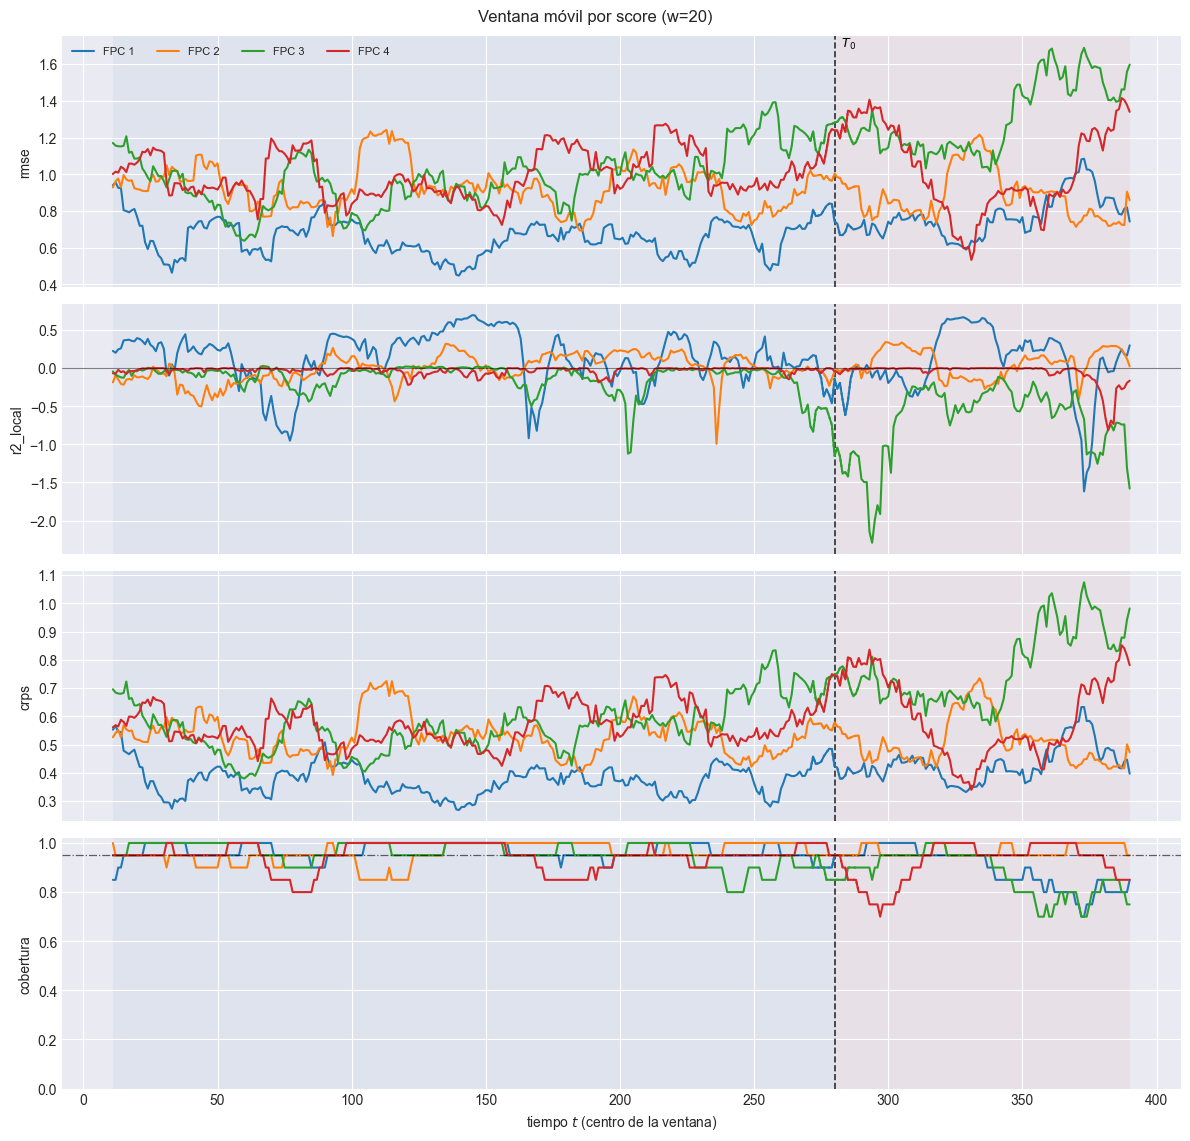

In [17]:
w_ref = VENTANAS_W[len(VENTANAS_W) // 2]
tablas_score = {
    w: ventana_movil_scores(
        Y_obs, Y_hat, T0_orig, w=w, muestras=SC_draws, li=li_s, ls=ls_s,
        t_offset=N_LAGS,
        etiquetas=[f"FPC {i + 1}" for i in COMPONENT_IDX],
        verbose=(w == w_ref))
    for w in VENTANAS_W
}
tablas_score[w_ref].to_csv(PATHS["out_report"] / f"56_ventana_scores_w{w_ref}.csv",
                           index=False)

plot_ventana_movil(
    tablas_score[w_ref], T0, ["rmse", "r2_local", "crps", "cobertura"],
    columna_grupo="componente",
    title=f"Ventana móvil por score (w={w_ref})",
    save_path=str(PATHS["out_report"] / "56_ventana_scores.png"),
    verbose=True)
plt.show()

[ventana_movil_funcional[w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=0.0s eta=0.6s  t=11 [train] mise=1.535
  19/380 ( 5.0%) t=0.0s eta=0.1s  t=29 [train] mise=0.9345
  38/380 (10.0%) t=0.0s eta=0.1s  t=48 [train] mise=1.182
  57/380 (15.0%) t=0.0s eta=0.1s  t=67 [train] mise=0.7335
  76/380 (20.0%) t=0.0s eta=0.1s  t=86 [train] mise=1.117
  95/380 (25.0%) t=0.0s eta=0.1s  t=105 [train] mise=1.093
  114/380 (30.0%) t=0.0s eta=0.1s  t=124 [train] mise=0.9083
  133/380 (35.0%) t=0.0s eta=0.1s  t=143 [train] mise=0.7671
  152/380 (40.0%) t=0.0s eta=0.1s  t=162 [train] mise=1.001
  171/380 (45.0%) t=0.0s eta=0.0s  t=181 [train] mise=0.944
  190/380 (50.0%) t=0.0s eta=0.0s  t=200 [train] mise=1.051
  209/380 (55.0%) t=0.0s eta=0.0s  t=219 [train] mise=0.9929
  228/380 (60.0%) t=0.0s eta=0.0s  t=238 [train] mise=1.139
  247/380 (65.0%) t=0.1s eta=0.0s  t=257 [train] mise=0.8625
  266/380 (70.0%) t=0.1s eta=0.0s  t=276 [train] mise=1.318
  285/380 (75.0%) t=0.1s eta=0.0s  t=295 [test] mise=1.

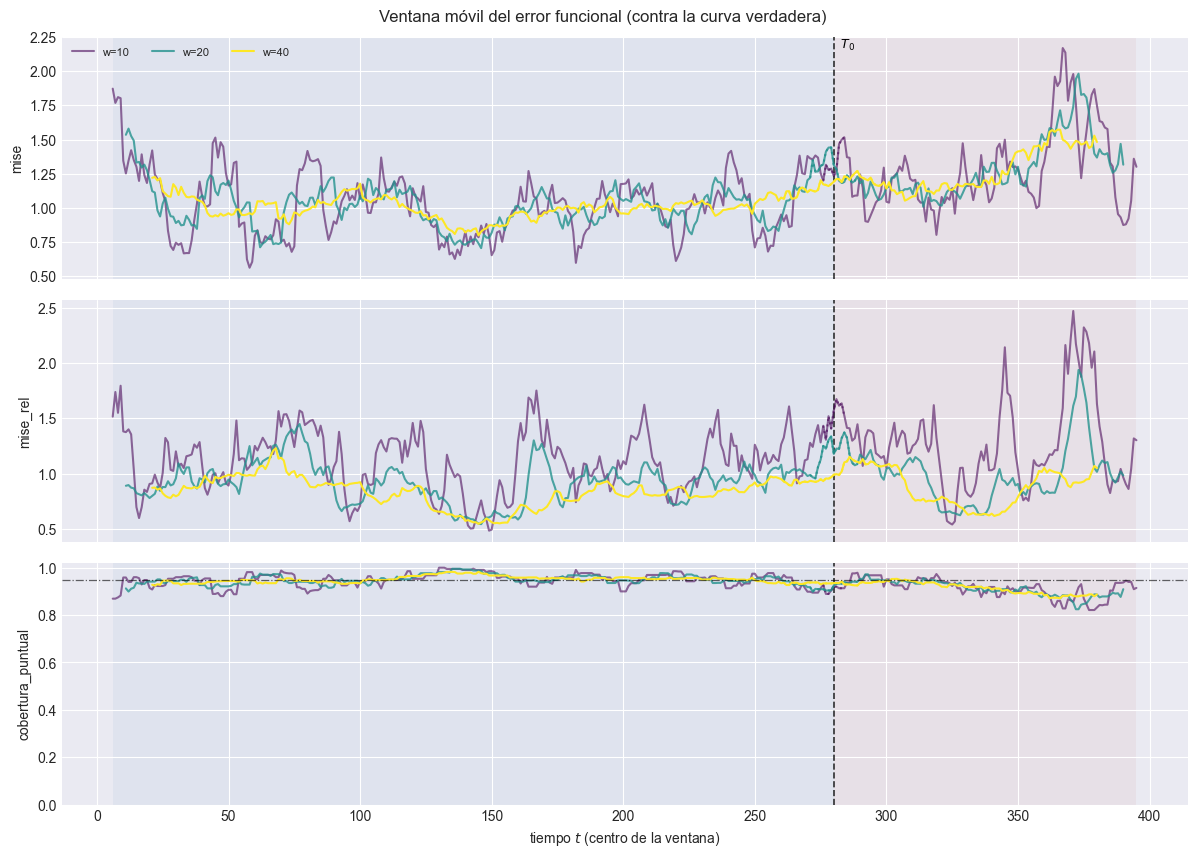

In [18]:
tablas_fun = {
    w: ventana_movil_funcional(X_true_ev, X_pred, grilla, T0_orig, w=w,
                               li=li_f, ls=ls_f, t_offset=N_LAGS,
                               verbose=(w == w_ref))
    for w in VENTANAS_W
}
tablas_fun[w_ref].to_csv(PATHS["out_report"] / f"57_ventana_funcional_w{w_ref}.csv",
                         index=False)

plot_ventana_movil(
    tablas_fun[w_ref], T0, ["mise", "mise_rel", "cobertura_puntual"],
    tablas_por_w=tablas_fun,
    title="Ventana móvil del error funcional (contra la curva verdadera)",
    save_path=str(PATHS["out_report"] / "57_ventana_funcional.png"),
    verbose=True)
plt.show()

In [19]:
# Salto en T0 y —lo propio de este escenario— PENDIENTE dentro del test.
print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}  "
      f"{'pend/100t':>10}  {'R2 recta':>9}")
print(f"{'─'*4}  {'─'*11}  {'─'*11}  {'─'*7}  {'─'*10}  {'─'*9}")
resumen_vm = []
for w in VENTANAS_W:
    t_ = tablas_fun[w]
    limpio = t_[~t_["cruza_T0"]]
    a = limpio.loc[limpio.bloque == "train", "mise"].mean()
    b = limpio.loc[limpio.bloque == "test",  "mise"].mean()

    # Recta sobre las ventanas de TEST que no cruzan: pendiente por 100 períodos.
    sub = limpio[limpio.bloque == "test"]
    col_t = "t_centro" if "t_centro" in sub.columns else sub.columns[0]
    xs = sub[col_t].to_numpy(dtype=float); ys = sub["mise"].to_numpy(dtype=float)
    if len(xs) > 3:
        Z = np.column_stack([np.ones(len(xs)), xs])
        cf = np.linalg.lstsq(Z, ys, rcond=None)[0]
        pend100 = float(cf[1]) * 100.0
        r2r = float(1 - ((ys - Z @ cf) ** 2).sum() / max(((ys - ys.mean()) ** 2).sum(), 1e-12))
    else:
        pend100, r2r = np.nan, np.nan
    print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}×  {pend100:>10.4f}  {r2r:>9.3f}")
    resumen_vm.append({"w": w, "mise_train": a, "mise_test": b, "salto": b / a,
                       "pendiente_test_por100t": pend100, "r2_recta": r2r})

pd.DataFrame(resumen_vm).to_csv(PATHS["out_report"] / "57b_ventana_pendiente.csv",
                                index=False)
print("\nLectura: en la corrida 11 el salto era ≈1.0 y la pendiente ≈0 (curva plana).")
print("Aquí una pendiente positiva con R² alto confirma DERIVA ACUMULÁNDOSE y no un")
print("escalón. Si la pendiente fuese ≈0 con salto grande, el fallo sería de nivel")
print("puntual y no de tendencia.")

   w   MISE train    MISE test    salto   pend/100t   R2 recta
────  ───────────  ───────────  ───────  ──────────  ─────────
  10     1.020631     1.274520    1.25×      0.3945      0.185
  20     1.005103     1.292906    1.29×      0.5408      0.516
  40     0.997769     1.281576    1.28×      0.6282      0.833

Lectura: en la corrida 11 el salto era ≈1.0 y la pendiente ≈0 (curva plana).
Aquí una pendiente positiva con R² alto confirma DERIVA ACUMULÁNDOSE y no un
escalón. Si la pendiente fuese ≈0 con salto grande, el fallo sería de nivel
puntual y no de tendencia.


## 8. Calibración

Bajo calibración perfecta el PIT es uniforme. La **forma** dice qué falla: una
U indica bandas demasiado angostas, una campana demasiado anchas, y una
**pendiente** un sesgo del centro.

En este escenario se espera precisamente la **pendiente**, y en el test debe ser
mucho más marcada que en train. Un PIT en U diría que el problema es de ancho
—banda subdimensionada—; un PIT inclinado dice que es de **centro**, que es la
hipótesis del escenario y lo que §9 cuantifica.

[plot_calibracion_pit] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.1s  FPC 1  train: media=0.501 desv_max=0.219 n=279  |  test: media=0.344 desv_max=1.333 n=120
  2/4 (50.0%) t=0.1s eta=0.1s  FPC 2  train: media=0.496 desv_max=0.355 n=279  |  test: media=0.511 desv_max=0.417 n=120
  3/4 (75.0%) t=0.1s eta=0.0s  FPC 3  train: media=0.501 desv_max=0.319 n=279  |  test: media=0.287 desv_max=2.333 n=120
  4/4 (100.0%) t=0.1s eta=0.0s  FPC 4  train: media=0.500 desv_max=0.211 n=279  |  test: media=0.516 desv_max=0.333 n=120
[plot_calibracion_pit] listo: 4 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_A_r01\58_pit.png


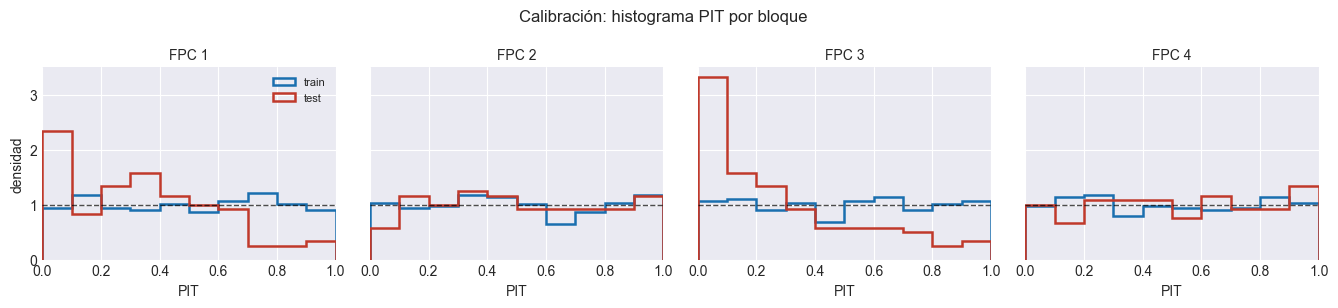

  FPC 1:  train KS=0.029 (aproximadamente uniforme)   test KS=0.253 (aproximadamente uniforme)   media PIT test=0.344
  FPC 2:  train KS=0.042 (aproximadamente uniforme)   test KS=0.047 (aproximadamente uniforme)   media PIT test=0.511
  FPC 3:  train KS=0.039 (aproximadamente uniforme)   test KS=0.344 (U (subdispersion: intervalos demasiado angostos))   media PIT test=0.287
  FPC 4:  train KS=0.034 (aproximadamente uniforme)   test KS=0.044 (aproximadamente uniforme)   media PIT test=0.516

La MEDIA del PIT en test es la cifra directa del sesgo de centro: bajo
calibración vale 0.5. Alejarse de 0.5 de forma sistemática y en la misma
dirección en todas las componentes es la firma de una deriva no modelada.


In [20]:
pit_tr = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[es_train, k],
                                                    SC_draws[:, es_train, k])
          for k in range(n_components)}
pit_te = {f"FPC {COMPONENT_IDX[k]+1}": pit_muestral(Y_obs[~es_train, k],
                                                    SC_draws[:, ~es_train, k])
          for k in range(n_components)}

plot_calibracion_pit(pit_tr, pit_te,
                     save_path=str(PATHS["out_report"] / "58_pit.png"),
                     verbose=True)
plt.show()

filas_pit = []
for nombre in pit_tr:
    d_tr, d_te = diagnostico_pit(pit_tr[nombre]), diagnostico_pit(pit_te[nombre])
    filas_pit.append({"FPC": nombre,
                      "ks_train": d_tr["ks"], "forma_train": d_tr["forma"],
                      "ks_test":  d_te["ks"], "forma_test":  d_te["forma"],
                      "media_pit_test": float(np.mean(pit_te[nombre]))})
    print(f"  {nombre}:  train KS={d_tr['ks']:.3f} ({d_tr['forma']})   "
          f"test KS={d_te['ks']:.3f} ({d_te['forma']})   "
          f"media PIT test={np.mean(pit_te[nombre]):.3f}")
pd.DataFrame(filas_pit).to_csv(PATHS["out_report"] / "58_pit.csv", index=False)

print("\nLa MEDIA del PIT en test es la cifra directa del sesgo de centro: bajo")
print("calibración vale 0.5. Alejarse de 0.5 de forma sistemática y en la misma")
print("dirección en todas las componentes es la firma de una deriva no modelada.")

## 9. Anatomía del fallo — **la sección propia del Escenario A**

Las secciones anteriores establecen *que* el modelo falla fuera de muestra.
Ésta responde *por qué*, y la distinción tiene consecuencias prácticas
opuestas:

- si el error es de **nivel** —la banda tiene el ancho y la forma correctos pero
  está desplazada—, la conclusión es que el pipeline necesita una etapa de
  **des-tendenciado** previa, y ningún modelo más flexible sobre la misma
  representación lo arreglará;
- si el error es de **forma** —la curva predicha tiene un perfil distinto en
  $\tau$—, entonces la base perdió vigencia y el problema es de representación,
  como en el Algoritmo 6.

### 9.1 Descomposición nivel / forma

Se define el **predictor con nivel corregido por oráculo**

$$\tilde X_t(\tau) \;=\; \hat X_t(\tau) \;+\; \overline{\big(X_t - \hat X_t\big)},$$

donde la barra promedia sobre $\tau$. Es decir: a cada origen se le regala el
nivel exacto y se le deja sólo el error de forma. Entonces

$$\underbrace{\mathrm{MISE}(\hat X)}_{\text{total}} \;-\;
  \underbrace{\mathrm{MISE}(\tilde X)}_{\text{forma}} \;=\; \text{error de nivel}.$$

**Es un oráculo y hay que declararlo así**: usa la curva verdadera para fijar el
nivel, de modo que `MISE_forma` es una **cota optimista** y no el desempeño de
un método alternativo. Su valor es diagnóstico —la *proporción*, no el nivel
absoluto—, exactamente como la base reajustada sobre el test en la corrida 16.

In [21]:
# Corrección de nivel por oráculo: se regala el nivel exacto en cada origen.
sesgo_nivel = (X_true_ev - X_pred).mean(axis=1)            # (n_orig,)
X_pred_forma = X_pred + sesgo_nivel[:, None]               # sólo queda error de forma

filas_desc = []
for mask, etq in ((es_train, "train"), (~es_train, "test")):
    m_tot   = mise(X_true_ev[mask], X_pred[mask],       grilla)
    m_forma = mise(X_true_ev[mask], X_pred_forma[mask], grilla)
    filas_desc.append({
        "bloque": etq,
        "MISE_total": m_tot,
        "MISE_forma": m_forma,
        "MISE_nivel": m_tot - m_forma,
        "frac_nivel": (m_tot - m_forma) / max(m_tot, 1e-12),
        "frac_forma": m_forma / max(m_tot, 1e-12),
        "sesgo_medio": float(sesgo_nivel[mask].mean()),
        "sesgo_abs_medio": float(np.abs(sesgo_nivel[mask]).mean()),
        "n": int(mask.sum()),
    })
desc_df = pd.DataFrame(filas_desc).set_index("bloque")
desc_df.to_csv(PATHS["out_report"] / "60_descomposicion_nivel_forma.csv")

display(desc_df.style
    .format({"MISE_total": "{:.6f}", "MISE_forma": "{:.6f}", "MISE_nivel": "{:.6f}",
             "frac_nivel": "{:.1%}", "frac_forma": "{:.1%}",
             "sesgo_medio": "{:+.4f}", "sesgo_abs_medio": "{:.4f}"})
    .set_caption("Descomposición del MISE · nivel corregido por ORÁCULO "
                 "(cota optimista, no un método)"))

f_niv_test = float(desc_df.loc["test", "frac_nivel"])
print(f"\nEn el bloque de PRUEBA, {f_niv_test:.1%} del MISE es error de NIVEL.")
print("─" * 66)
if f_niv_test > 0.7:
    print("VEREDICTO: el fallo es de NIVEL, no de forma.")
    print("  ⇒ La banda está bien dimensionada pero mal centrada.")
    print("  ⇒ Un modelo predictivo más flexible sobre esta misma representación")
    print("    NO resolvería el problema: se necesita des-tendenciar antes del FPCA.")
    print("  ⇒ La pérdida es de VIGENCIA DEL CENTRADO, no de generalización.")
elif f_niv_test > 0.4:
    print("VEREDICTO: mixto. Nivel y forma contribuyen de forma comparable.")
    print("  ⇒ Revisar TEND_INCLINACION: si es != 0, la deriva contamina la forma")
    print("    por construcción y los dos efectos están mezclados a propósito.")
else:
    print("VEREDICTO: el fallo es de FORMA.")
    print("  ⇒ Inesperado con inclinación 0. Sugiere que la base perdió vigencia")
    print("    (efecto (2) de 17_01 §0), no sólo el centrado. Contrastar con el")
    print("    MISE del truncamiento por bloque, impreso en §3.1.")
print("─" * 66)
print(f"\nsesgo medio de nivel: train {desc_df.loc['train','sesgo_medio']:+.4f}  ·  "
      f"test {desc_df.loc['test','sesgo_medio']:+.4f}")
print("Un sesgo de test POSITIVO significa que el modelo predice POR DEBAJO de la")
print("curva verdadera, que es lo esperado con deriva creciente.")

,MISE_total,MISE_forma,MISE_nivel,frac_nivel,frac_forma,sesgo_medio,sesgo_abs_medio,n
bloque,,,,,,,,
train,1.039711,0.592073,0.447639,43.1%,56.9%,-0.0057,0.5370,279
test,1.282739,0.614703,0.668036,52.1%,47.9%,+0.4987,0.6473,120



En el bloque de PRUEBA, 52.1% del MISE es error de NIVEL.
──────────────────────────────────────────────────────────────────
VEREDICTO: mixto. Nivel y forma contribuyen de forma comparable.
  ⇒ Revisar TEND_INCLINACION: si es != 0, la deriva contamina la forma
    por construcción y los dos efectos están mezclados a propósito.
──────────────────────────────────────────────────────────────────

sesgo medio de nivel: train -0.0057  ·  test +0.4987
Un sesgo de test POSITIVO significa que el modelo predice POR DEBAJO de la
curva verdadera, que es lo esperado con deriva creciente.


### 9.2 El sesgo contra el estado verdadero

Si la interpretación de §9.1 es correcta, el sesgo de nivel de cada origen debe
ser una función **casi lineal** de $b(t)$: el modelo se queda anclado al nivel
medio del entrenamiento y el desfase es exactamente la deriva no vista.

La regresión de la celda siguiente es la prueba cuantitativa. Una pendiente
cercana a $\overline{g(\tau)}$ con $R^2$ alto cierra el argumento: el error es
la deriva, medida directamente.

sesgo_nivel(t)  ~  a + c · b(t)
  pendiente c   = +0.3283     (g_medio = 1.0000)
  intercepto a  = -0.3477
  R²            = 0.1650
  corr(b, sesgo)= +0.4062


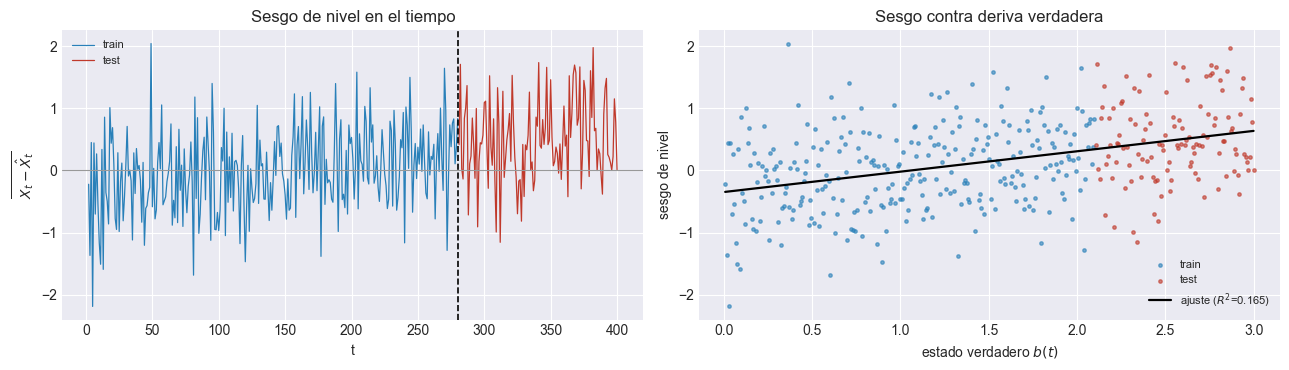


⚠ La relación sesgo↔deriva es débil. El modelo está absorbiendo parte de
  la deriva por el canal del rezago propio (raíz cuasi-unitaria), lo cual
  atenúa el sesgo pero no lo elimina. Reportar ambas cifras.


In [22]:
Z = np.column_stack([np.ones(n_orig), b_t_ev])
cf = np.linalg.lstsq(Z, sesgo_nivel, rcond=None)[0]
r2_sesgo = float(1 - ((sesgo_nivel - Z @ cf) ** 2).sum()
                 / max(((sesgo_nivel - sesgo_nivel.mean()) ** 2).sum(), 1e-12))
corr_sesgo = float(np.corrcoef(b_t_ev, sesgo_nivel)[0, 1])

print(f"sesgo_nivel(t)  ~  a + c · b(t)")
print(f"  pendiente c   = {cf[1]:+.4f}     (g_medio = {float(TEND['g_medio']):.4f})")
print(f"  intercepto a  = {cf[0]:+.4f}")
print(f"  R²            = {r2_sesgo:.4f}")
print(f"  corr(b, sesgo)= {corr_sesgo:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

ax = axes[0]
ax.plot(t_orig[es_train], sesgo_nivel[es_train], lw=0.9, color="#2980b9", label="train")
ax.plot(t_orig[~es_train], sesgo_nivel[~es_train], lw=0.9, color="#c0392b", label="test")
ax.axvline(T0, color="k", ls="--", lw=1.2); ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("t"); ax.set_ylabel(r"$\overline{X_t - \hat X_t}$")
ax.set_title("Sesgo de nivel en el tiempo"); ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(b_t_ev[es_train], sesgo_nivel[es_train], s=6, color="#2980b9",
           alpha=0.6, label="train")
ax.scatter(b_t_ev[~es_train], sesgo_nivel[~es_train], s=6, color="#c0392b",
           alpha=0.6, label="test")
bb = np.linspace(b_t_ev.min(), b_t_ev.max(), 50)
ax.plot(bb, cf[0] + cf[1] * bb, color="k", lw=1.6,
        label=rf"ajuste ($R^2$={r2_sesgo:.3f})")
ax.set_xlabel(r"estado verdadero $b(t)$"); ax.set_ylabel("sesgo de nivel")
ax.set_title("Sesgo contra deriva verdadera"); ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PATHS["out_report"] / "61_sesgo_vs_deriva.png", dpi=150, bbox_inches="tight")
plt.show()

if r2_sesgo > 0.7 and abs(cf[1]) > 0.3 * float(TEND["g_medio"]):
    print("\n✓ El sesgo de nivel ES la deriva no vista. El diagnóstico de §9.1 queda\n"
          "  cerrado: no hay nada que un modelo predictivo pueda hacer con esto.")
else:
    print("\n⚠ La relación sesgo↔deriva es débil. El modelo está absorbiendo parte de\n"
          "  la deriva por el canal del rezago propio (raíz cuasi-unitaria), lo cual\n"
          "  atenúa el sesgo pero no lo elimina. Reportar ambas cifras.")

### 9.3 Cobertura condicional estratificada por el estado verdadero

Cuarto punto de la Etapa C, con `fit.estratos_por_cuantil` y
`fit.cobertura_condicional`. El estado es $b(t)$ y **se cuantiliza** —al
contrario que en el Algoritmo 3, donde el régimen es discreto y se pasa
directo.

**Aquí es donde vive la advertencia**, y se repite por tercera vez a propósito:
$b(t)$ es monótona en $t$, de modo que los estratos son intervalos temporales
contiguos. El estrato Q4 es esencialmente el final del bloque de prueba y el Q1
el principio del entrenamiento. Esta tabla y la de §4 **miden lo mismo desde
dos ángulos**. Su valor añadido no es descubrir un efecto nuevo sino mostrar la
**monotonía**: la cobertura debe degradarse de forma ordenada Q1→Q4, no caer de
golpe. Una caída en escalón indicaría que el problema es el corte $T_0$ y no la
deriva.

In [23]:
n_estr = int(EST.get("n_estratos", 4))
etiquetas_estr = list(EST.get("etiquetas", [f"q{i+1}" for i in range(n_estr)]))

estratos, etiquetas_estr = estratos_por_cuantil(b_t_ev, n_estratos=n_estr,
                                                etiquetas=etiquetas_estr)

cc_fun = pd.DataFrame(cobertura_condicional(
    X_true_ev, li_f, ls_f, estratos, etiquetas=etiquetas_estr,
    tau=grilla, muestras=X_draws))
cc_fun.to_csv(PATHS["out_report"] / "62_cobertura_condicional_funcional.csv", index=False)

# Composición temporal de cada estrato: la evidencia de la advertencia.
comp = []
for e, etq in enumerate(etiquetas_estr):
    m = estratos == e
    comp.append({"estrato": etq, "n": int(m.sum()),
                 "t_min": int(t_orig[m].min()), "t_max": int(t_orig[m].max()),
                 "b_medio": float(b_t_ev[m].mean()),
                 "frac_test": float((~es_train[m]).mean())})
comp_df = pd.DataFrame(comp)

display(cc_fun.style.format({c: "{:.4f}" for c in cc_fun.columns
                             if cc_fun[c].dtype.kind == "f"})
        .set_caption("Cobertura condicional de la CURVA por estrato de deriva"))
display(comp_df.style.format({"b_medio": "{:.3f}", "frac_test": "{:.1%}"})
        .set_caption("Composición temporal de cada estrato — la advertencia, medida"))

print("\n⚠ " + EST["advertencia"])

# Monotonía: la cifra que sí aporta esta sección.
col_cob = "cobertura" if "cobertura" in cc_fun.columns else cc_fun.columns[1]
cobs = cc_fun[col_cob].to_numpy(dtype=float)
print(f"\ncobertura por estrato (Q1→Q{n_estr}): "
      f"{np.array2string(cobs, precision=3)}")
print(f"  monótona decreciente: {bool(np.all(np.diff(cobs) <= 1e-9))}")
print("  Monótona ⇒ la degradación sigue a la DERIVA de forma ordenada.")
print("  En escalón ⇒ el corte T0 domina y el efecto no es la deriva.")

,estrato,n,cobertura,ancho_medio,desvio,energy
0,deriva Q1,100,0.9337,3.9611,-0.0036,5.9693
1,deriva Q2,99,0.9624,3.9689,0.0251,5.6053
2,deriva Q3,100,0.9458,3.9882,0.0085,5.9939
3,deriva Q4,100,0.9076,4.1842,-0.0297,6.4845


,estrato,n,t_min,t_max,b_medio,frac_test
0,deriva Q1,100,2,101,0.380,0.0%
1,deriva Q2,99,102,200,1.128,0.0%
2,deriva Q3,100,201,300,1.876,20.0%
3,deriva Q4,100,301,400,2.628,100.0%



⚠ b(t) es MONOTONA en t, de modo que los estratos por nivel de deriva son intervalos temporales contiguos y el estrato mas alto coincide casi exactamente con el bloque de prueba. La cobertura condicional de 17_04 §9 y la comparacion train/test de 17_04 §4 miden por tanto LO MISMO. Es la tesis del escenario, no un defecto, pero sin declararlo el desplome de cobertura se leeria como perdida de GENERALIZACION cuando es perdida de VIGENCIA DEL CENTRADO. Para separar ambos efectos habria que usar TEND_FORMA='cuadratica', que concentra la deriva dentro del test.

cobertura por estrato (Q1→Q4): [0.934 0.962 0.946 0.908]
  monótona decreciente: False
  Monótona ⇒ la degradación sigue a la DERIVA de forma ordenada.
  En escalón ⇒ el corte T0 domina y el efecto no es la deriva.


In [24]:
# El mismo ejercicio por score, para ver si la degradación se concentra en la
# componente de la deriva o se reparte entre todas.
filas_cc_s = []
for k in range(n_components):
    fpc = COMPONENT_IDX[k] + 1
    cc = cobertura_condicional(Y_obs[:, k], li_s[:, k], ls_s[:, k], estratos,
                               etiquetas=etiquetas_estr,
                               muestras=SC_draws[:, :, k])
    for fila in cc:
        fila = dict(fila)
        fila["FPC"] = fpc
        fila["es_deriva"] = bool(fpc == FPC_DERIVA)
        filas_cc_s.append(fila)

cc_scores = pd.DataFrame(filas_cc_s)
cc_scores.to_csv(PATHS["out_report"] / "63_cobertura_condicional_scores.csv", index=False)
display(cc_scores.style.format({c: "{:.4f}" for c in cc_scores.columns
                                if cc_scores[c].dtype.kind == "f"})
        .set_caption("Cobertura condicional por score y estrato de deriva"))

_der = cc_scores[cc_scores.es_deriva][col_cob].to_numpy(dtype=float)
_otr = cc_scores[~cc_scores.es_deriva].groupby("estrato")[col_cob].mean() \
       if "estrato" in cc_scores.columns else None
print(f"\ncobertura de la FPC {FPC_DERIVA} (deriva) por estrato: "
      f"{np.array2string(_der, precision=3)}")
print("Si la degradación se concentra ahí, la deriva está localizada en una sola")
print("dirección del espacio funcional y un des-tendenciado de UNA componente")
print("bastaría. Si se reparte, hace falta des-tendenciar la curva completa.")

,estrato,n,cobertura,ancho_medio,desvio,crps,FPC,es_deriva
0,deriva Q1,100,0.9400,2.7354,0.0002,0.4179,1,True
1,deriva Q2,99,0.9798,2.7014,0.0399,0.3523,1,True
2,deriva Q3,100,0.9600,2.7361,0.0202,0.3798,1,True
3,deriva Q4,100,0.8800,3.0334,-0.0598,0.4324,1,True
4,deriva Q1,100,0.9500,3.7563,-0.0099,0.5134,2,False
5,deriva Q2,99,0.9596,3.7718,-0.0003,0.5582,2,False
6,deriva Q3,100,0.9700,3.7654,0.0101,0.5269,2,False
7,deriva Q4,100,0.9600,3.7568,0.0001,0.5114,2,False
8,deriva Q1,100,0.9700,3.9472,0.0427,0.5449,3,False
9,deriva Q2,99,0.9697,3.9483,0.0424,0.5293,3,False



cobertura de la FPC 1 (deriva) por estrato: [0.94 0.98 0.96 0.88]
Si la degradación se concentra ahí, la deriva está localizada en una sola
dirección del espacio funcional y un des-tendenciado de UNA componente
bastaría. Si se reparte, hace falta des-tendenciar la curva completa.


## 10. Comparación con las líneas base

Ver `17_01 §6.1`: bajo tendencia la comparación relevante es contra
**persistencia**, no contra la media incondicional.

- **PSBP-FD < persistencia** ⇒ el modelo aporta pese a la mala especificación.
- **PSBP-FD ≳ persistencia** ⇒ el modelo no supera al des-tendenciado trivial
  que la persistencia implementa implícitamente, y ése es el resultado
  reportable del escenario: no un fallo del PSBP-FD, sino la demostración de
  que la etapa de representación decide antes de que el modelo intervenga.

In [25]:
_bl = PATHS["out_report"] / "30_baselines_test.csv"
rmse_psbp = met_df.loc["test", "RMSE"].mean()
print(f"RMSE promedio en scores — PSBP-FD (test): {rmse_psbp:.4f}\n")

veredicto_bl = None
if _bl.exists():
    baselines_df = pd.read_csv(_bl, index_col=0)
    display(baselines_df.style.format("{:.4f}", na_rep="—")
            .set_caption("Líneas base sobre el bloque de prueba (h=1)"))
    if "RMSE_scores_prom" in baselines_df.columns:
        for modelo, fila in baselines_df.iterrows():
            marca = "✓ PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"] else "✗ baseline mejor"
            peso = "  ← LA comparación que importa" if "persistencia" in str(modelo) else ""
            print(f"  vs {modelo:24s} RMSE={fila['RMSE_scores_prom']:.4f}  → {marca}{peso}")
        if "persistencia_lag1" in baselines_df.index:
            r_per = float(baselines_df.loc["persistencia_lag1", "RMSE_scores_prom"])
            veredicto_bl = bool(rmse_psbp < r_per)
            print(f"\n  PSBP / persistencia = {rmse_psbp / r_per:.3f}")
            if veredicto_bl:
                print("  ⇒ El PSBP-FD aporta sobre el des-tendenciado trivial.")
            else:
                print("  ⇒ El PSBP-FD NO supera a la persistencia. Resultado reportable:\n"
                      "    la representación decide antes de que el modelo intervenga.")
else:
    print("⚠ falta 30_baselines_test.csv — ejecuta 17_01 §6.1.")

print("\nNota: sólo hay dos líneas base (media incondicional y persistencia). FAR(1),\n"
      "VAR sobre scores y ARIMA por score siguen pendientes en fit/baselines.py.")

RMSE promedio en scores — PSBP-FD (test): 1.0203



,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,120.0000,1.8024,0.9352,1.3666,1.0711,1.2938,-0.7210,4.0817,2.0203
persistencia_lag1,120.0000,0.6871,1.1180,1.3906,1.4187,1.1536,-0.3403,1.3886,1.1784


  vs media_incondicional      RMSE=1.2938  → ✓ PSBP mejor
  vs persistencia_lag1        RMSE=1.1536  → ✓ PSBP mejor  ← LA comparación que importa

  PSBP / persistencia = 0.884
  ⇒ El PSBP-FD aporta sobre el des-tendenciado trivial.

Nota: sólo hay dos líneas base (media incondicional y persistencia). FAR(1),
VAR sobre scores y ARIMA por score siguen pendientes en fit/baselines.py.


## 11. Resumen ejecutable

In [26]:
resumen = {
    "experiment_id": EXPERIMENT_ID,
    "escenario": "A — FAR(1) con tendencia determinista",
    "objetivo_evaluacion": OBJETIVO,
    "modo_residuo": MODO_RESIDUO,
    "nivel": NIVEL,
    # tendencia
    "deriva_total": float(TEND["deriva_total"]),
    "tendencia_forma": TEND["forma"],
    "tendencia_inclinacion": float(TEND["inclinacion"]),
    "fpc_deriva": int(FPC_DERIVA),
    # predicción
    "S_scores": int(S_total), "S_funcional": int(X_draws.shape[0]),
    "rmse_scores_train": float(met_df.loc["train", "RMSE"].mean()),
    "rmse_scores_test":  float(met_df.loc["test", "RMSE"].mean()),
    "rmse_ratio_test_train": float(_deg),
    "rmse_ratio_c11_ref": RMSE_RATIO_C11,
    "mise_train": float(fun_df.loc["train", "MISE"]),
    "mise_test":  float(fun_df.loc["test", "MISE"]),
    "mise_truncamiento_test": float(fun_df.loc["test", "MISE_truncamiento"]),
    "cobertura_puntual_train": float(fun_df.loc["train", f"Cob{int(NIVEL*100)}_puntual"]),
    "cobertura_puntual_test":  float(fun_df.loc["test",  f"Cob{int(NIVEL*100)}_puntual"]),
    # anatomía del fallo
    "frac_mise_nivel_test": float(desc_df.loc["test", "frac_nivel"]),
    "frac_mise_forma_test": float(desc_df.loc["test", "frac_forma"]),
    "sesgo_nivel_test": float(desc_df.loc["test", "sesgo_medio"]),
    "sesgo_vs_deriva_pendiente": float(cf[1]),
    "sesgo_vs_deriva_r2": float(r2_sesgo),
    "g_medio": float(TEND["g_medio"]),
    "pendiente_mise_test_por100t": float(resumen_vm[len(resumen_vm)//2]["pendiente_test_por100t"]),
    "psbp_supera_persistencia": veredicto_bl,
}
pd.Series(resumen).to_csv(PATHS["out_report"] / "59_resumen.csv", header=False)
for k, v in resumen.items():
    print(f"  {k:30s}: {v}")

print("\n" + "═" * 70)
print("LECTURA FINAL DEL ESCENARIO A")
print("═" * 70)
print(f"  degradación RMSE test/train : {_deg:.2f}×   (corrida 11: {RMSE_RATIO_C11})")
print(f"  cobertura funcional         : {resumen['cobertura_puntual_train']:.3f} (train) "
      f"→ {resumen['cobertura_puntual_test']:.3f} (test)")
print(f"  fracción del MISE de NIVEL  : {resumen['frac_mise_nivel_test']:.1%}")
print(f"  sesgo ≈ deriva              : pendiente {cf[1]:+.3f} vs g_medio "
      f"{float(TEND['g_medio']):.3f}, R²={r2_sesgo:.3f}")
print("─" * 70)
print("Al reportar, declarar SIEMPRE las tres cosas:")
print("  1. El error del test es mayoritariamente de NIVEL (si §9.1 lo confirma):")
print("     pérdida de vigencia del centrado, no de generalización.")
print("  2. Los estratos de §9.3 coinciden con la partición train/test porque b(t)")
print("     es monótona; §9.3 y §4 miden lo mismo.")
print("  3. El eje 3 (PIP, 17_03 §6.1) es NO informativo aquí: la correlación del")
print("     propio rezago es espuria por raíz común.")
print("═" * 70)
print(f"\nFiguras y tablas en {PATHS['out_report']}")

  experiment_id                 : escenario_A_r01
  escenario                     : A — FAR(1) con tendencia determinista
  objetivo_evaluacion           : curva_verdadera
  modo_residuo                  : ninguno
  nivel                         : 0.95
  deriva_total                  : 3.0
  tendencia_forma               : lineal
  tendencia_inclinacion         : 0.0
  fpc_deriva                    : 1
  S_scores                      : 450000
  S_funcional                   : 500
  rmse_scores_train             : 0.905413526569432
  rmse_scores_test              : 1.0203040141539468
  rmse_ratio_test_train         : 1.1268928331784807
  rmse_ratio_c11_ref            : 1.027
  mise_train                    : 1.0397114642033307
  mise_test                     : 1.2827393391556088
  mise_truncamiento_test        : 0.04104279196807054
  cobertura_puntual_train       : 0.9466188769414576
  cobertura_puntual_test        : 0.914
  frac_mise_nivel_test          : 0.5207889642020085
  frac_mise